In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.collections import PathCollection, PolyCollection
import matplotlib as mpl
import string

In [2]:
df = pd.read_csv("Params_data.csv",header=0)

In [3]:
# Filter data based on keywords
Development_Eggs = df[(df['Definition'].str.contains('Development', case=False, na=False)) & 
                        (df['Lifestage'].str.contains('Eggs', case=False, na=False))]
Development_Larvae = df[(df['Definition'].str.contains('Development', case=False, na=False)) & 
                        (df['Lifestage'].str.contains('Larvae', case=False, na=False))]
Development_Pupae = df[(df['Definition'].str.contains('Development', case=False, na=False)) & 
                        (df['Lifestage'].str.contains('Pupae', case=False, na=False))]
Transition_Gravid = df[(df['Definition'].str.contains('Transition', case=False, na=False)) & 
                        (df['Lifestage'].str.contains('Gravid', case=False, na=False))]
Mortality_Eggs = df[(df['Definition'].str.contains('Mortality', case=False, na=False)) & 
                        (df['Lifestage'].str.contains('Egg', case=False, na=False))]
Mortality_Larvae = df[(df['Definition'].str.contains('Mortality', case=False, na=False)) & 
                        (df['Lifestage'].str.contains('Larvae', case=False, na=False))]
Mortality_Pupae = df[(df['Definition'].str.contains('Mortality', case=False, na=False)) & 
                        (df['Lifestage'].str.contains('Pupae', case=False, na=False))]
Mortality_Adults = df[(df['Definition'].str.contains('Mortality', case=False, na=False)) & 
                        (df['Lifestage'].str.contains('Adults', case=False, na=False))]

In [4]:
# Find the axis limits for each subset
def get_axis_limits(df_subset):
    temp_min = df_subset['Temperature'].min()-2
    temp_max = df_subset['Temperature'].max()+2
    if df_subset['Value'].mean() < 1:
        value_min = df_subset['Value'].min()-0.1
        value_max = df_subset['Value'].max()+0.1
    else:
        value_min = df_subset['Value'].min()-10
        value_max = df_subset['Value'].max()+10
    return temp_min, temp_max, value_min, value_max

# Get axis limits for each subset
dev_eggs_limits = get_axis_limits(Development_Eggs)
dev_larvae_limits = get_axis_limits(Development_Larvae)
dev_pupae_limits = get_axis_limits(Development_Pupae)
mortality_eggs_limits = get_axis_limits(Mortality_Eggs)
mortality_larvae_limits = get_axis_limits(Mortality_Larvae)
mortality_pupae_limits = get_axis_limits(Mortality_Pupae)
mortality_adults_limits = get_axis_limits(Mortality_Adults)
transition_gravid_limits = get_axis_limits(Transition_Gravid)

In [5]:
# Define the models
def linear_model(x, a, b):
    return a + b * x

def quadratic_model(x, a, b, c):
    return a + b * x + c * x**2

def logan_model(x, psi, rho, Tmax, deltaT):
    return psi * (np.exp(rho * x) - np.exp(rho * Tmax - ((Tmax - x) / deltaT)))

In [6]:
# Define aicc

def calculate_aicc(n, residuals, k):
    rss = np.sum(residuals**2)

    aic = n * np.log((rss) / n) + 2 * k
    
    # Avoid division by zero or negative denominator
    if n - k - 1 <= 0:
        return np.nan
    
    aicc = aic + (2 * k * (k + 1)) / (n - k - 1)
    return aicc

In [7]:
# Fit a specified model to a dataset subset and evaluate it using AICc

def fit_and_compare(df_subset, model_type, name=None):
    x_data = df_subset['Temperature']
    y_data = df_subset['Value']

    if model_type == 'linear':
        if len(x_data) < 2:
            return None, None, None, None
        popt, pcov = curve_fit(linear_model, x_data, y_data)
        residuals = y_data - linear_model(x_data, *popt)
        aic = calculate_aicc(len(x_data), residuals, 2)
        fitted_y = linear_model(x_data, *popt)
            
    elif model_type == 'quadratic':
        if len(x_data) < 3:
            return None, None, None, None
        popt, pcov = curve_fit(quadratic_model, x_data, y_data)
        residuals = y_data - quadratic_model(x_data, *popt)
        aic = calculate_aicc(len(x_data), residuals, 3)
        fitted_y = quadratic_model(x_data, *popt)
            
    elif model_type == 'logan':
        if len(x_data) < 5:
            return None, None, None, None
    
        # Initial parameter guesses
        psi_guess = 0.001
        rho_guess = 0.15
        Tmax_guess = 35
        deltaT_guess = 3
    
        p0 = [psi_guess, rho_guess, Tmax_guess, deltaT_guess]
    
        # Bounds
        bounds = (
            [0,      0,    30,  0.1],   # lower
            [1,      1,    45,  20]     # upper
        )
    
        popt, pcov = curve_fit(logan_model, x_data, y_data, p0=p0, bounds=bounds, maxfev=20000)
        residuals = y_data - logan_model(x_data, *popt)
        aic = calculate_aicc(len(x_data), residuals, 4)
        fitted_y = logan_model(x_data, *popt)
            
    return aic, fitted_y, popt, pcov

In [8]:
# Fit all candidate models to each dataset subset and compare AICc values
models = ['linear', 'quadratic', 'logan']
results = {}

# Initialize dictionaries to store the results for each model
fitting_params = {}
aic_values = {}

# List of all the 8 subsets
subsets = {
    "Development_Eggs": Development_Eggs,
    "Development_Larvae": Development_Larvae,
    "Development_Pupae": Development_Pupae,
    "Mortality_Eggs": Mortality_Eggs,
    "Mortality_Larvae": Mortality_Larvae,
    "Mortality_Pupae": Mortality_Pupae,
    "Mortality_Adults": Mortality_Adults,
    "Transition_Gravid": Transition_Gravid
}

limits = {
    "Development_Eggs": dev_eggs_limits,
    "Development_Larvae": dev_larvae_limits,
    "Development_Pupae": dev_pupae_limits,
    "Mortality_Eggs": mortality_eggs_limits,
    "Mortality_Larvae": mortality_larvae_limits,
    "Mortality_Pupae": mortality_pupae_limits,
    "Mortality_Adults": mortality_adults_limits,
    "Transition_Gravid": transition_gravid_limits
}

# Loop through each model
for model in models:
    results[model] = {}
    
    # Loop through each of the 8 subsets
    for name, subset in subsets.items():
        T_max = subset['Temperature'].max()  # Get the maximum temperature
        T_min = subset['Temperature'].min()  # Get the minimum temperature
        
        # Fit the model and get AICc value
        aicc_value, fitted_y, popt, pcov = fit_and_compare(subset, model, name=name)
        
        # Store the results for the current model and subset
        results[model][name] = aicc_value
        fitting_params[(name, model)] = (popt, pcov)
    
# Display the AIC values for each model and subset
for model in models:
    print(f"\nAICc values for {model} model:")
    for name in results[model]:
        print(f"{name}: {results[model][name]}")

# Identify the best model for each dataset
best_models = {}
for name in subsets.keys():
    if name == "Mortality_Pupae":  # Enforce quadratic model for Mortality_Pupae
        best_models[name] = 'quadratic'
    else:
        # Filter out models with None AICc values
        valid_models = [model for model in models if results[model][name] is not None]
        
        if valid_models:
            best_model = min(valid_models, key=lambda model: results[model][name])  # Model with the lowest AICc
        else:
            # If no valid models, default to a model (e.g., 'linear')
            best_model = 'linear' 
        
        best_models[name] = best_model

# Display the best fitting models with their parameters and equations
for name, best_model in best_models.items():
    print(f"\nBest fitting model for {name}: {best_model.capitalize()}")

    params = fitting_params.get((name, best_model), (None, None))
    popt, pcov = params

    if popt is not None:
        if best_model == 'linear':
            print(f"Fitted function: y = a + b * T (a = {popt[0]}, b = {popt[1]})")
        elif best_model == 'quadratic':
            print(f"Fitted function: y = a + b * T + c * T^2 (a = {popt[0]}, b = {popt[1]}, c = {popt[2]})")
        elif best_model == 'logan':
            print(f"Fitted function: y = psi * (exp(rho*T) - exp(rho*Tmax - ((Tmax-T)/deltaT))) (psi = {popt[0]:.6f}, rho = {popt[1]:.6f}, Tmax = {popt[2]:.4f},  deltaT = {popt[3]:.4f})")
    else:
        print(f"Warning: No fitted parameters available for {best_model} model for {name}.")


C:\Users\S3897561\AppData\Local\Temp\ipykernel_47712\760544960.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(quadratic_model, x_data, y_data)



AICc values for linear model:
Development_Eggs: -55.00738578625797
Development_Larvae: -148.6647692479797
Development_Pupae: -79.10854821571388
Mortality_Eggs: -14.967679572880877
Mortality_Larvae: -46.074185917549116
Mortality_Pupae: -73.08976342919334
Mortality_Adults: nan
Transition_Gravid: -69.38583096615515

AICc values for quadratic model:
Development_Eggs: -50.949581224596145
Development_Larvae: -149.55989188992353
Development_Pupae: -77.10116574305405
Mortality_Eggs: -30.459224587614877
Mortality_Larvae: -71.28409512185557
Mortality_Pupae: -70.35427918835501
Mortality_Adults: nan
Transition_Gravid: -64.63693882045574

AICc values for logan model:
Development_Eggs: -44.033931593533005
Development_Larvae: -146.71130705673008
Development_Pupae: -73.8095819231047
Mortality_Eggs: -6.700784010653685
Mortality_Larvae: -38.27163958623542
Mortality_Pupae: -66.99859798802379
Mortality_Adults: None
Transition_Gravid: -54.42491213389017

Best fitting model for Development_Eggs: Linear
Fit

In [9]:
def is_valid_covariance_matrix(cov):
    if cov is None:
        return False
    if np.any(np.isnan(cov)) or np.any(np.isinf(cov)):
        return False
    # Check if symmetric
    if not np.allclose(cov, cov.T):
        return False
    # Check positive semi-definite: all eigenvalues >= 0
    eigvals = np.linalg.eigvalsh(cov)
    if np.any(eigvals < -1e-8):  # small negative tolerance for numerical errors
        return False
    return True

In [10]:
def ezanno_eggs_dev_rate(T):
    return np.maximum(0.16 * (np.exp(0.105*(T - 10)) - np.exp(0.105*(35 - 10) - (35 - T)/5.007)), 0)

def ezanno_larvae_dev_rate(T):
    return (0.021 * (np.exp(0.162*(T - 10)) - np.exp(0.162*(35 - 10) - (35 - T)/5.007))) / 4

def ezanno_pupae_dev_rate(T):
    return 0.021 * (np.exp(0.162*(T - 10)) - np.exp(0.162*(35 - 10) - (35 - T)/5.007))

def ezanno_eggs_mortality_rate(T):
    return np.full_like(T, 0.0262)

def ezanno_larvae_mortality_rate(T):
    return np.exp(-T/2) + 0.0304

def ezanno_pupae_mortality_rate(T):
    return np.exp(-T/2) + 0.0146

def ezanno_adult_mortality_rate(T):
    return np.maximum(-0.005941 + 0.002965*T, 1/43)

def ezanno_oviposition_rate_nulliparous(T):
    return np.full_like(T, 141)

def ezanno_oviposition_rate_parous(T):
    return np.full_like(T, 80)

def ezanno_gravid_transition_rate(T):
    return np.maximum((T - 9.8)/64.4, 0)

In [11]:
ezanno_functions = {
    'Development_Eggs': ezanno_eggs_dev_rate,
    'Development_Larvae': ezanno_larvae_dev_rate,
    'Development_Pupae': ezanno_pupae_dev_rate,
    'Mortality_Eggs': ezanno_eggs_mortality_rate,
    'Mortality_Larvae': ezanno_larvae_mortality_rate,
    'Mortality_Pupae': ezanno_pupae_mortality_rate,
    'Mortality_Adults': ezanno_adult_mortality_rate,
    'Oviposition': (ezanno_oviposition_rate_nulliparous, ezanno_oviposition_rate_parous),
    'Transition_Gravid': ezanno_gravid_transition_rate
}

In [12]:
mpl.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    # Axis lines
    "axes.linewidth": 0.55,

    # Tick thickness
    "xtick.major.width": 0.55,
    "ytick.major.width": 0.55,
    "xtick.minor.width": 0.45,
    "ytick.minor.width": 0.45,

    # Tick length (optional but helpful)
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Line plots
    "lines.linewidth": 1,

    # Fonts
    "font.family": "Arial",

    # PDF export
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

In [13]:
letters = list(string.ascii_uppercase)

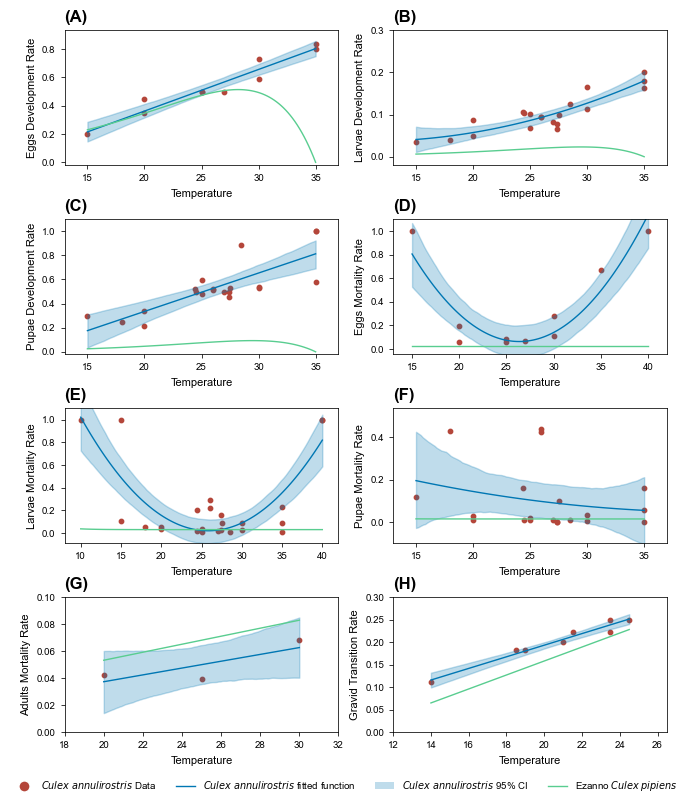

In [14]:
fig_width = 170 / 25.4
fig_height = 205 / 25.4
plt.figure(figsize=(fig_width, fig_height))
n_samples = 1000  # Number of Monte Carlo simulations

# Store legend proxies
seen_labels = set()
proxy_handles = []
proxy_labels = []

for i, (name, subset) in enumerate(subsets.items()):
    ax = plt.subplot(4, 2, i + 1)

    sc = ax.scatter(subset['Temperature'], subset['Value'], color='#B4463A', s=10, label=r'$\mathit{Culex}$ $\mathit{annulirostris}$ Data')
    ax.set_xlabel('Temperature')
    ax.set_ylabel(f'{" ".join(name.split("_")[::-1])} Rate')

    popt, pcov = fitting_params.get((name, best_models[name]), (None, None))
    best_model = best_models[name]

    if popt is not None and pcov is not None:
        T = np.linspace(subset['Temperature'].min(), subset['Temperature'].max(), 100)

        if best_model == 'linear':
            fitted_y = linear_model(T, *popt)
        elif best_model == 'quadratic':
            fitted_y = quadratic_model(T, *popt)
        elif best_model == 'briere':
            Tmin, Tmax = T.min(), T.max()
            fitted_y = briere_model(T, *popt, Tmin, Tmax, m=2)
        elif best_model == 'custom':
            fitted_y = custom_model(T, *popt)
        else:
            fitted_y = None

        if is_valid_covariance_matrix(pcov):
            param_samples = np.random.multivariate_normal(popt, pcov, size=n_samples)
            all_y_preds = []
            for sample_params in param_samples:
                if best_model == 'linear':
                    y_pred = linear_model(T, *sample_params)
                elif best_model == 'quadratic':
                    y_pred = quadratic_model(T, *sample_params)
                elif best_model == 'briere':
                    y_pred = briere_model(T, *sample_params, Tmin, Tmax, m=2)
                elif best_model == 'custom':
                    y_pred = custom_model(T, *sample_params)
                all_y_preds.append(y_pred)

            all_y_preds = np.array(all_y_preds)
            lower_bound = np.percentile(all_y_preds, 2.5, axis=0)
            upper_bound = np.percentile(all_y_preds, 97.5, axis=0)

            line, = ax.plot(T, fitted_y, label=rf'$\mathit{{Culex}}$ $\mathit{{annulirostris}}$ fitted function', color='#0077B3')
            fill = ax.fill_between(T, lower_bound, upper_bound, color='#0077B3', alpha=0.25, label=r'$\mathit{Culex}$ $\mathit{annulirostris}$ 95% CI')
        else:
            line, = ax.plot(T, fitted_y, label=f'{best_model} fit', color='#0077B3')

    # Add Ezanno et al. 2015 function
    ezanno_func = ezanno_functions.get(name, None)
    if ezanno_func is not None:
        ez_curve = ezanno_func(T)
        ax.plot(T, ez_curve, color='#59CD90', linestyle='-', label=r'Ezanno $\mathit{Culex}$ $\mathit{pipiens}$')

    # Add panel label (letter) in bold in the top left
    ax.text(
        0, 1.15,
        f'({letters[i]})',
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        verticalalignment='top',
        horizontalalignment='left'
    )

    # Axis limits
    temp_min, temp_max, value_min, value_max = limits[name]
    ax.set_xlim(temp_min, temp_max)
    if name == "Development_Pupae":
        value_min = -0.02
    if name == "Development_Larvae":
        value_min = -0.02
    if name == "Development_Eggs":
        value_min = -0.02
    if name == "Mortality_Adults":
        value_min = 0
        value_max = 0.10
    if name == "Transition_Gravid":
        value_min = 0
        value_max = 0.30
    ax.set_ylim(value_min, value_max)
    ax.tick_params(axis='both')

    # Collect legend entries for proxy legend
    handles, labels = ax.get_legend_handles_labels()
    for h, l in zip(handles, labels):
        if l not in seen_labels:
            seen_labels.add(l)
            if isinstance(h, Line2D):
                proxy = Line2D([0], [0], color=h.get_color(), linestyle=h.get_linestyle())
            elif isinstance(h, Patch):
                proxy = Patch(facecolor=h.get_facecolor()[0], alpha=h.get_alpha())
            elif isinstance(h, PathCollection):
                proxy = Line2D([0], [0], marker='o', color='w',
                               markerfacecolor=h.get_facecolor()[0], markersize=8, linestyle='')
            elif isinstance(h, PolyCollection):
                proxy = Patch(facecolor=h.get_facecolor()[0], alpha=h.get_alpha())
            else:
                continue
            proxy_handles.append(proxy)
            proxy_labels.append(l)

# Shared legend at bottom
plt.figlegend(
    handles=proxy_handles,
    labels=proxy_labels,
    loc='lower center',
    ncol=4,
    fontsize = 7,
    frameon=False
)
plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.95,
    bottom=0.08,
    hspace=0.4,
    wspace=0.2
)
plt.show()